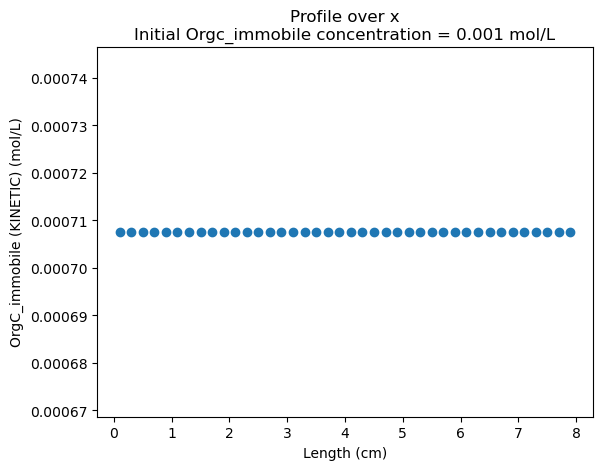

In [5]:
# %load make_plot_CNC.py
import flopy
import matplotlib.pyplot as plt
from rtmf6.postprocessing.output_reader import ShelveViewer
import numpy as np

#%% Shelve
viewer = ShelveViewer('rtmf6.toml') ## load from selected output

#%% LOAD MODEL
sim_name = 'cat_ex_1d'
gwf_name = f'gwf_{sim_name}'
gwt_name = f'gwt_{sim_name}'
sim_ws = './mf6'

sim = flopy.mf6.MFSimulation.load(
    sim_name,
    'mf6',
    exe_name='mf6',
    sim_ws=sim_ws,
    verbosity_level=0,
)

gwf = sim.get_model(gwf_name)

mg = gwf.modelgrid
x = mg.xcellcenters
y = mg.ycellcenters

#%% extract from selected output
ntimes = gwf.modeltime.nstp[-1]
Orgc_im = viewer.selected_output.selected_output_1.get_value(ntimes)['Orgc_im']
Orgc = viewer.selected_output.selected_output_1.get_value(ntimes)['Orgc']

plt.plot(x[0,:]*100,Orgc_im[0,0,:],'o')
plt.xlabel('Length (cm)')
plt.ylabel('OrgC_immobile (KINETIC) (mol/L)')
plt.title('Profile over x\nInitial Orgc_immobile concentration = 0.001 mol/L');


In [6]:
import numpy as np

In [65]:
nlay=3
nrow=4
ncol=5


a = np.arange(36, 36 + nlay * nrow * ncol).reshape(nlay, nrow, ncol)
flat_a = a.flatten()

In [34]:
a

array([[[36, 37, 38, 39, 40],
        [41, 42, 43, 44, 45],
        [46, 47, 48, 49, 50],
        [51, 52, 53, 54, 55]],

       [[56, 57, 58, 59, 60],
        [61, 62, 63, 64, 65],
        [66, 67, 68, 69, 70],
        [71, 72, 73, 74, 75]],

       [[76, 77, 78, 79, 80],
        [81, 82, 83, 84, 85],
        [86, 87, 88, 89, 90],
        [91, 92, 93, 94, 95]]], shape=(3, 4, 5))

In [63]:
active = np.ones_like(a, dtype=bool)
active[:,0] = False
active[:,:, 0] = False
active

array([[[False, False, False, False, False],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True]],

       [[False, False, False, False, False],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True]],

       [[False, False, False, False, False],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True],
        [False,  True,  True,  True,  True]]], shape=(3, 4, 5))

In [123]:
flat_active = active.flatten()
domain = flat_a[flat_active]

In [67]:
sel = flat_a[flat_active]

In [83]:
rec = np.rec.array(
    [
        ((0, 2, 2), 0., 0.),
        ((2, 1, 3), 0., 0.),
    ],
    dtype=[('cellid', 'O'), ('conc', '<f8'), ('rtmf6_sol_number', '<f8')])
cncs = rec['cellid']
cncs

array([(0, 2, 2), (2, 1, 3)], dtype=object)

In [95]:
np.array([(0, 2, 2), (2, 1, 3)], dtype=object)

array([[0, 2, 2],
       [2, 1, 3]], dtype=object)

In [84]:
a[cncs[0]]

np.int64(48)

In [85]:
a[cncs[1]]

np.int64(84)

In [92]:
indices_3d = np.arange(a.size).reshape(a.shape)
indices_active = indices_3d[active]
indices_active

array([ 6,  7,  8, ..., 57, 58, 59], shape=(36,))

In [99]:
indices_active[indices_active == 12]

array([12])

In [143]:
sel = sorted(indices_3d[index] for index in cncs)
sel

[np.int64(12), np.int64(48)]

In [140]:
res = []
index_iter = enumerate(indices_active)
for cnc_index in sel:
    while True:
        res_index, old_index = next(index_iter)
        if cnc_index == old_index:
            res.append(res_index)
            break

In [147]:
res = []
index_iter = enumerate(indices_active)
for cnc_index in sel:
    for res_index, old_index in index_iter:
        print(res_index)
        if cnc_index == old_index:
            res.append(res_index)
            print('break')
            break
res

0
1
2
3
4
5
break
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
break


[5, 26]

In [126]:
np.where(indices_active == sel[1])

(array([26]),)

In [127]:
domain[[5, 26]]

array([48, 84])

In [136]:
[a[x] for x in cncs]

[np.int64(48), np.int64(84)]

In [137]:
list(cncs)

[(0, 2, 2), (2, 1, 3)]

In [48]:
from rtmf6.postprocessing.plot import plot_compare_rtmf6_pht3d
from rtmf6.config import Config

In [51]:
config = Config('rtmf6.toml')

In [52]:
plot_compare_rtmf6_pht3d

<function rtmf6.postprocessing.plot.plot_compare_rtmf6_pht3d(config, pht3d_file, components=('Na', 'Cl', 'K', 'Ca'), steps=None, save_fig=None)>

<Axes: xlabel='time (days)', ylabel=' concentrations (mmols/kgw)'>

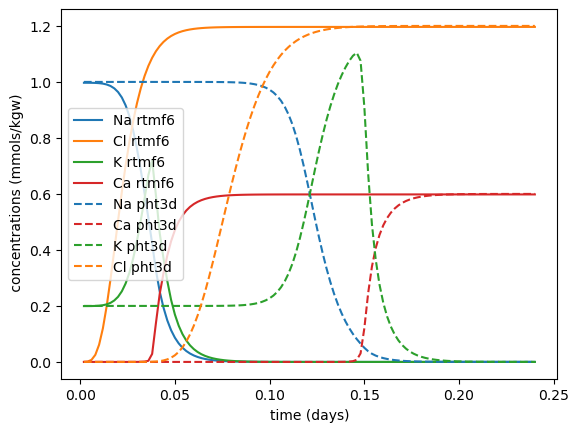

In [193]:
plot_compare_rtmf6_pht3d(
    config,
    pht3d_file='/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/pht3d/out.dat',
)

In [155]:
idomain_3d = np.ones_like(a, dtype=bool)
idomain_3d[:,0] = False
idomain_3d[:,:, 0] = False
idomain_3d
idomain = idomain_3d.flatten()
all_true = np.ones_like(a, dtype=bool)

In [159]:
mask = all_true.copy()
for cnc in cncs:
    mask[cnc] = False
flat_mask = mask.flatten()[idomain_3d.flatten()]

In [160]:
flat_mask

array([ True,  True,  True, ...,  True,  True,  True], shape=(36,))

In [163]:
np.argwhere(~flat_mask).flatten()

array([ 5, 26])

In [151]:
flat_a = a.flatten()

In [152]:
flat_a[idomain_3d.flatten()]

array([42, 43, 44, ..., 93, 94, 95], shape=(36,))

In [165]:
import shelve

In [185]:
db = shelve.open('/Users/mike/Dev/pymf6-project/rtmf6/tests/test_cnc_inactive/cation_exchange_1d_CNC_KINETIC/.internal/work/flopy/domain.db')
inact = db['inactive_indices']
inact

{0: array([(0, 0, 0)], dtype=object), 2: array([(0, 0, 0)], dtype=object)}

In [184]:
set(inact['cnc'].items())

TypeError: cannot use 'tuple' as a set element (unhashable type: 'numpy.ndarray')

In [177]:
db['inactive_indices']

{'cnc': {0: array([(0, 0, 0)], dtype=object),
  2: array([(0, 0, 0)], dtype=object)}}

In [186]:
from pymf6.api import States

In [190]:
nxyz = 38
inactive = [5, 26]
res = []
for index in range(nxyz - len(inactive)):
    if index in inactive:
        res.append(-1)
    res.append(index)

In [191]:
res

[0,
 1,
 2,
 3,
 4,
 -1,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 -1,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35]

In [194]:
import phreeqcrm

<frozen importlib._bootstrap>:491: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:491: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


In [197]:
dir(phreeqcrm)

['BMIPhreeqcRM',
 'BoolVector',
 'DoubleVector',
 'IRM_BADINSTANCE',
 'IRM_BADVARTYPE',
 'IRM_FAIL',
 'IRM_INVALIDARG',
 'IRM_INVALIDCOL',
 'IRM_INVALIDROW',
 'IRM_OK',
 'IRM_OUTOFMEMORY',
 'IntVector',
 'PhreeqcRM',
 'State',
 'StringVector',
 'YAMLPhreeqcRM',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_phreeqcrm',
 'phreeqcrm',
 'yamlphreeqcrm']

In [201]:
phreeqcrm.yamlphreeqcrm.__spec__

ModuleSpec(name='phreeqcrm.yamlphreeqcrm', loader=<_frozen_importlib_external.SourceFileLoader object at 0x1018a3110>, origin='/Users/mike/Dev/pymf6-project/rtmf6/.pixi/envs/default/lib/python3.14/site-packages/phreeqcrm/yamlphreeqcrm.py')

In [203]:
phreeqcrm._phreeqcrm

<module 'phreeqcrm._phreeqcrm' from '/Users/mike/Dev/pymf6-project/rtmf6/.pixi/envs/default/lib/python3.14/site-packages/phreeqcrm/_phreeqcrm.cpython-314-darwin.so'>

In [204]:
%ls /Users/mike/Dev/pymf6-project/rtmf6/.pixi/envs/default/lib/python3.14/site-packages/phreeqcrm/

__init__.py                       phreeqcrm.py
__pycache__/                      yamlphreeqcrm.py
_phreeqcrm.cpython-314-darwin.so*


/Users/mike/Dev/pymf6-project/rtmf6/.pixi/envs/default/lib/python3.14/pty.py:66: DeprecationWarning: This process (pid=16492) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [207]:
import pip

In [209]:
pip.main(['show', 'phreeqcrm'])

Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Name: phreeqcrm

Version: 0.0.16

Summary: A reaction module for transport simulators based on the geochemical model PHREEQC.

Home-page:

...

License:

Location: /Users/mike/Dev/pymf6-project/rtmf6/.pixi/envs/default/lib/python3.14/site-packages

Requires: numpy, PyYAML

Required-by:

0

In [210]:
from importlib.metadata import version

In [212]:
version('phreeqcrm')

'0.0.16'